# Classifier Attribution Timing Comparison

Сравнение пяти attribution methods для `yolo11s-cls`: `Full IG`, `Full IG` на сегменте, `NAA`, legacy `Cheap-IG` и корректный `Cheap-IG`, где exact IG считается только для выбранных нейронов.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT.parent))

from portable_cheap_naa_attack import (
    AttributionBenchmarkConfig,
    benchmark_classifier_attribution_runtimes,
    plot_classifier_runtime_barplot,
    plot_visual_examples_table,
    run_classifier_attribution_comparison,
)

ROOT


PosixPath('/Users/ashentide/PycharmProjects/PaperImplementations/portable_cheap_naa_attack')

In [ ]:
# Если ваши изображения лежат в ROOT / "dataset", этот блок подхватит их автоматически.
dataset_dir = ROOT / "dataset"
fallback_dir = ROOT.parent / "data"
image_dir = dataset_dir if dataset_dir.exists() else fallback_dir

image_paths = sorted(
    str(path.resolve())
    for path in image_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
)

if not image_paths:
    raise RuntimeError(f"No images found in {image_dir}")

visual_paths = image_paths[:3]
timing_paths = image_paths[:3]

config = AttributionBenchmarkConfig(
    layer_name="model.6",
    baseline_mode="zero",
    include_full_ig=False,
    n_steps=128,
    ranking_steps=8,
    segment_start=0.0,
    segment_end=0.1,
    selection_mode="signed",
    selection_top_k=4000,
    fill_mode="zero",
)

print("image_dir:", image_dir)
print("visual_paths:", len(visual_paths), visual_paths)
print("timing_paths:", len(timing_paths), timing_paths)
config


image_dir: /Users/ashentide/PycharmProjects/PaperImplementations/portable_cheap_naa_attack/dataset
visual_paths: 3 ['/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00000293.JPEG', '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00002138.JPEG', '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00003014.JPEG']
timing_paths: 3 ['/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00000293.JPEG', '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00002138.JPEG', '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00003014.JPEG']


AttributionBenchmarkConfig(weights_path=PosixPath('/Users/ashentide/PycharmProjects/PaperImplementations/portable_cheap_naa_attack/weights/yolo11s-cls.pt'), layer_name='model.6', baseline_mode='zero', image_size=224, include_full_ig=False, n_steps=256, ranking_steps=8, segment_start=0.0, segment_end=0.1, selection_mode='signed', selection_top_k=4000, fill_mode='zero', fill_rho=0.8, clear_every=8, force_device=None)

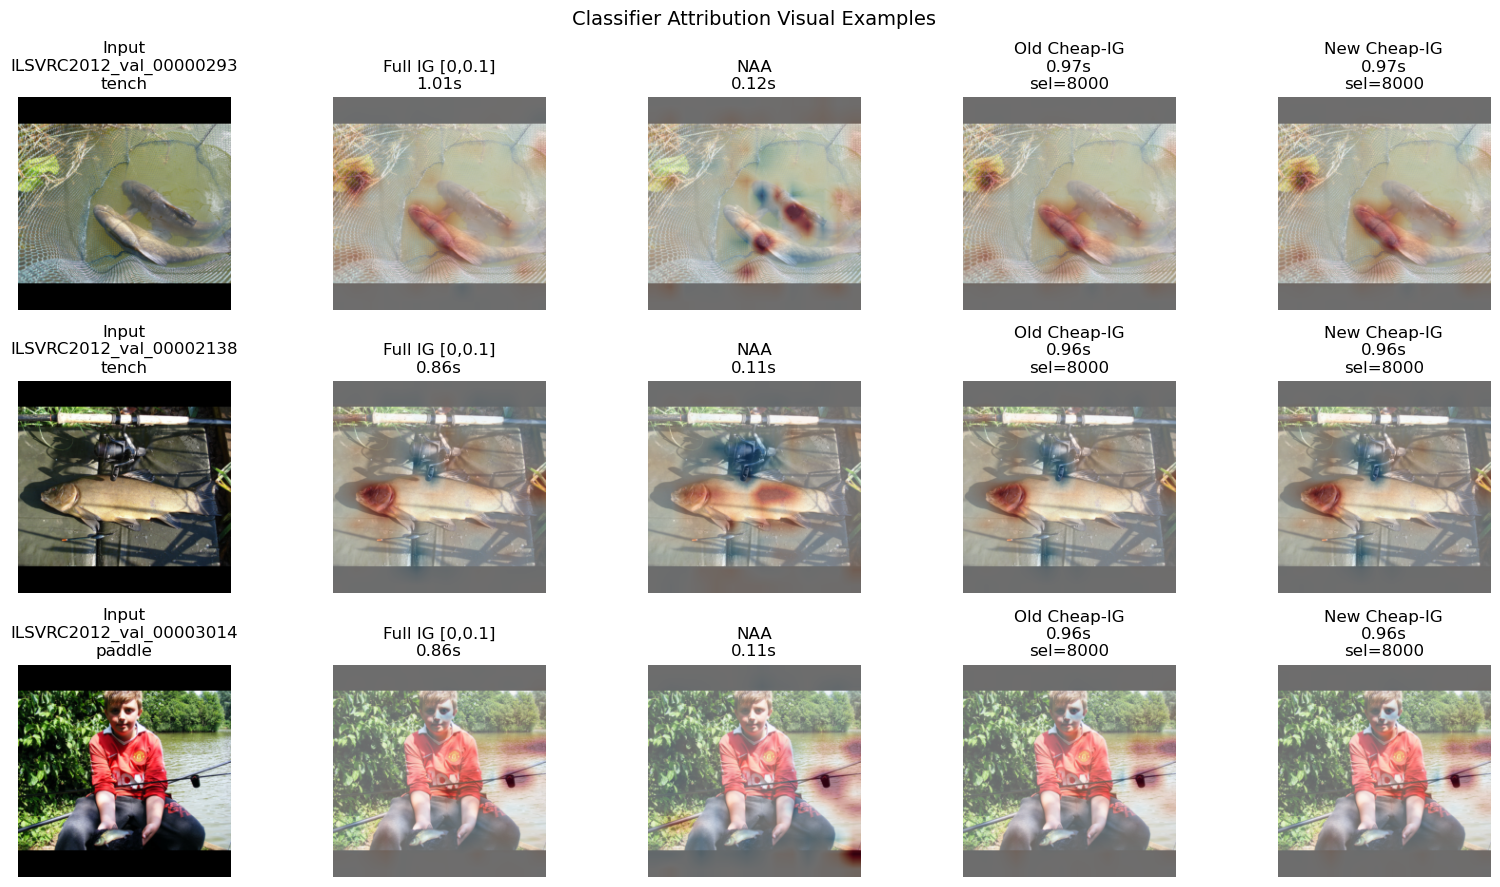

In [3]:
comparisons = [run_classifier_attribution_comparison(path, config) for path in visual_paths]
fig = plot_visual_examples_table(comparisons, config)
plt.show()


Full IG [0,0.1]: mean=0.855s std=0.012s runs=3
NAA: mean=0.120s std=0.010s runs=3
Old Cheap-IG: mean=0.968s std=0.012s runs=3
New Cheap-IG: mean=0.967s std=0.002s runs=3


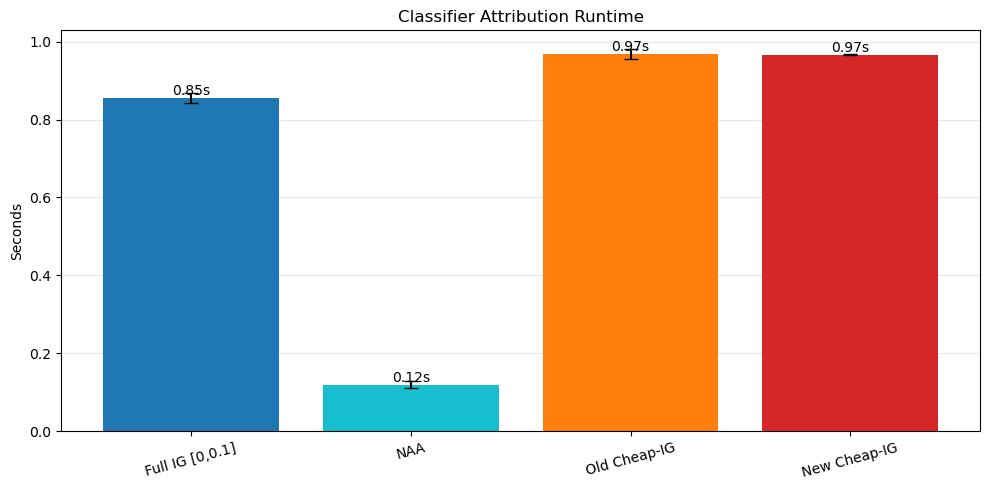

In [4]:
runtime_summary = benchmark_classifier_attribution_runtimes(
    timing_paths,
    config,
    repeats=1,
)

for method_name, stats in runtime_summary.items():
    print(f"{method_name}: mean={stats['mean_seconds']:.3f}s std={stats['std_seconds']:.3f}s runs={stats['num_runs']}")

fig = plot_classifier_runtime_barplot(runtime_summary)
plt.show()
